## Exotic searches at ATLAS with NN Classification

## Marking

You will get marks for completeing the different tasks within this notebook:

Any code expected for you to complete will contain `## FINISH ME` indicating the code isn't expected to run until you have completed it.


| <p align='left'> Title                         | <p align='left'> Number of marks |
| -------------------------------------  | --- |
| <p align='left'> Assessment Exercise 1                     | <p align='left'> 2 |
| <p align='left'> Assessment Exercise 2                     | <p align='left'> 2 |
| <p align='left'> Assessment Exercise 3                     | <p align='left'> 1 |
| <p align='left'> Assessment Exercise 4                                     | <p align='left'> 2 |
| <p align='left'> Assessment Exercise 5                               | <p align='left'> 2 |
| <p align='left'> Assessment Exercise 6                       | <p align='left'> 1 |
| <p align='left'> **Total** | <p align='left'> max **10** |

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
#  The next command should not be necessary, but may be used to force plots to appear inline in the notebook (if they're not showing up)
#  %matplotlib inline

### Assessment Exercise 1: Import, clean, and visualize data

In [2]:
import os    # for loading data from a local source

print("Current working directory:", os.getcwd())
foldername = 'C:\\Users\\ls3007\\Desktop\\AGQ_Computing\\Notebooks\\Files\\'
bgd_files = ['Diboson.csv','Top.csv','Zjets.csv']
sig_files = ['ggH1000.csv']

bgd_df = []
sig_df = []
all_files = bgd_files + sig_files

for index, file in enumerate(all_files):
    size = os.path.getsize(foldername + file)/(1024*1024)
    print ('Opening file',file,'with size',"{:.1f}".format(size),'MB:',)
    tmp = pd.read_csv(foldername + file, index_col=0)      # reads csv files into a pandas DataFrame
    if index < len(bgd_files):
        bgd_df.append(tmp)
    else:
        sig_df.append(tmp)
    print ('Done')
    

Current working directory: C:\Users\ls3007\Desktop\AGQ_Computing\Notebooks
Opening file Diboson.csv with size 32.1 MB:
Done
Opening file Top.csv with size 18.7 MB:
Done
Opening file Zjets.csv with size 1336.9 MB:
Done
Opening file ggH1000.csv with size 10.4 MB:
Done


In [3]:
# sanity check: check the first few rows and columns in the data
print(sig_df[0].iloc[:5,:12])
print(bgd_df[0].iloc[:5,:12])

   FullEventWeight        MET  Topology  Zll_mass     Zll_pt  fatjet_C2  \
0         0.013603  44495.770         1  87475.55  627990.80   0.116438   
1         0.242178  34441.156         1  90507.31  409780.94   0.191874   
2         0.096412  21625.379         0  89765.85  344668.30   0.122089   
3         0.096373  21855.973         1  92313.63  535629.06   0.061306   
4         0.073052  33677.380         1  89451.92  296257.47   0.159334   

   fatjet_D2   fatjet_E  fatjet_eta  fatjet_phi  fatjet_pt  isSignal  
0   0.889354  675246.25   -0.851387    2.042860  480641.84         1  
1   1.485706  604275.70    1.041311   -0.817613  375352.78         1  
2   1.219367  612517.94    0.417858   -2.133300  555879.20         1  
3   0.592705  482630.90    0.438590    2.701475  430646.20         1  
4   0.724910  459737.80    1.213717   -0.926707  244348.40         1  
   FullEventWeight         MET  Topology    Zll_mass      Zll_pt  fatjet_C2  \
0         0.387345   41920.540         0  18

In [4]:
# sanity check: check if cleaning is required to remove empty (NA) values -- and clean
print ("# of entries before cleaning S:\n", sig_df[0].count())
print ("# of entries before cleaning B0:\n", bgd_df[0].count())
print ("# of entries before cleaning B1:\n", bgd_df[1].count())
print ("# of entries before cleaning B2:\n", bgd_df[2].count())
sig_df[0].dropna(inplace = True)
bgd_df[0].dropna(inplace=True)
bgd_df[1].dropna(inplace=True)
bgd_df[2].dropna(inplace=True)
print ("# of entries after cleaning S:\n", sig_df[0].count())
print ("# of entries after cleaning B0:\n", bgd_df[0].count())
print ("# of entries after cleaning B1:\n", bgd_df[1].count())
print ("# of entries after cleaning B2:\n", bgd_df[2].count())

# of entries before cleaning S:
 FullEventWeight    50013
MET                50013
Topology           50013
Zll_mass           50013
Zll_pt             50013
fatjet_C2          50013
fatjet_D2          50013
fatjet_E           50013
fatjet_eta         50013
fatjet_phi         50013
fatjet_pt          50013
isSignal           50013
lep1_E             50013
lep1_charge        50013
lep1_eta           50013
lep1_phi           50013
lep1_pt            50013
lep2_E             50013
lep2_charge        50013
lep2_eta           50013
lep2_phi           50013
lep2_pt            50013
reco_zv_mass       50013
truth_zv_mass      50013
dtype: int64
# of entries before cleaning B0:
 FullEventWeight    155127
MET                155127
Topology           155127
Zll_mass           155127
Zll_pt             155127
fatjet_C2          155127
fatjet_D2          155127
fatjet_E           155127
fatjet_eta         155127
fatjet_phi         155127
fatjet_pt          155127
isSignal           155127
lep1_E  

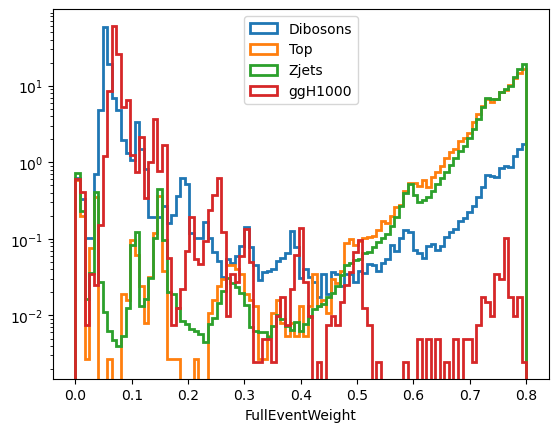

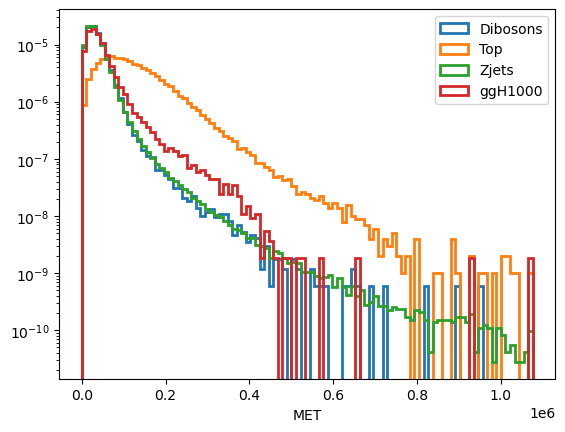

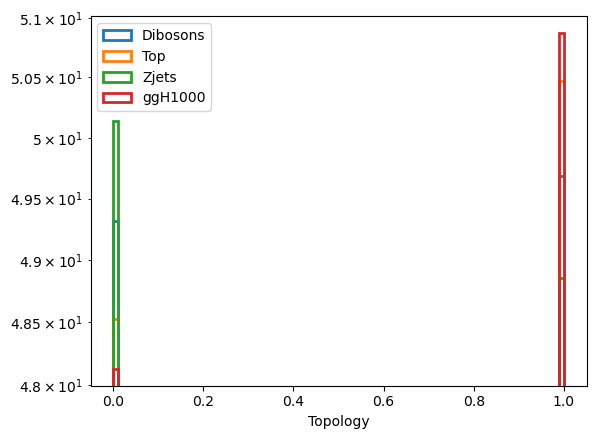

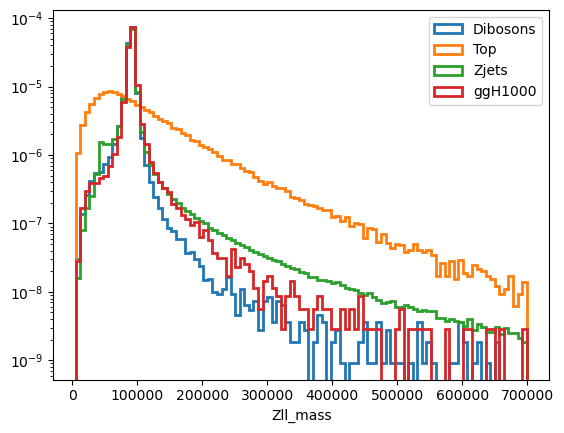

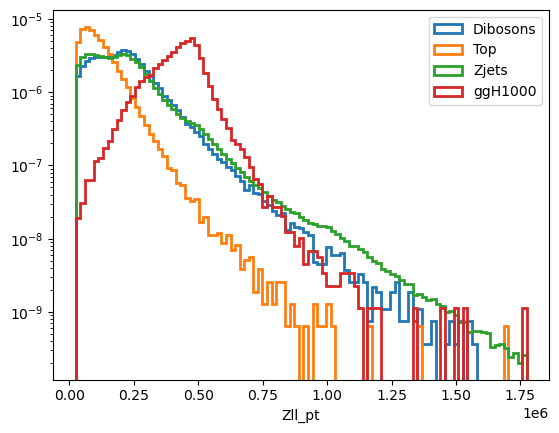

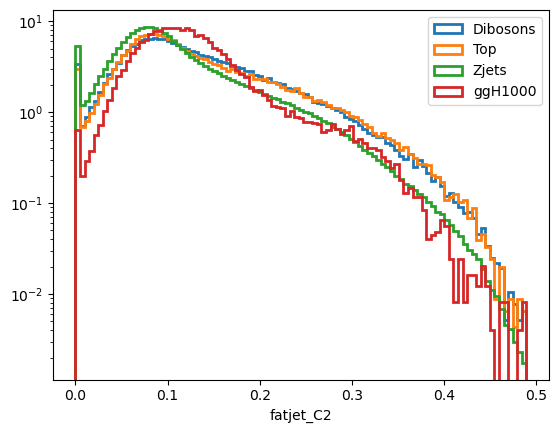

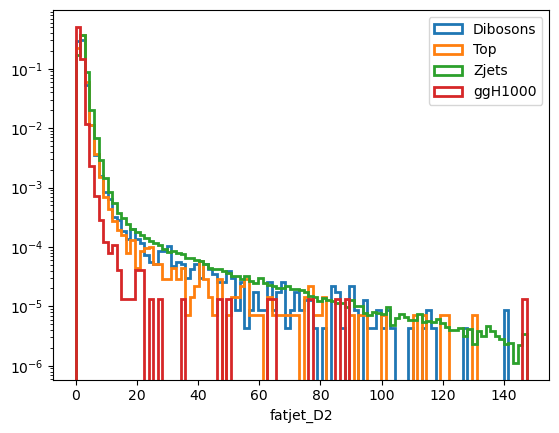

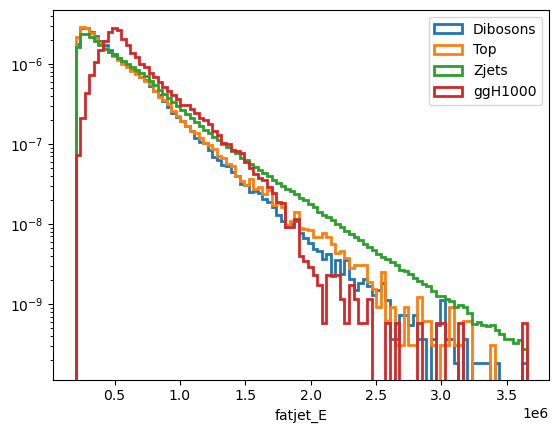

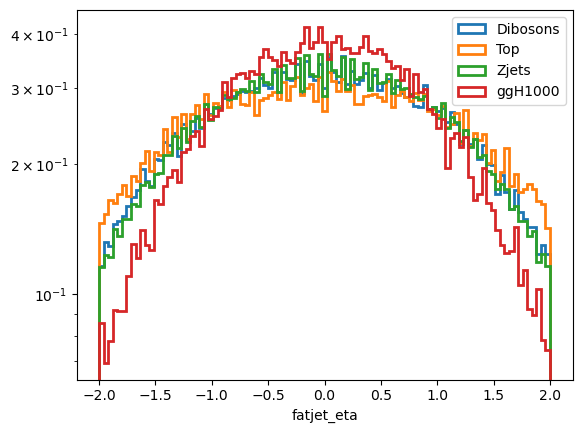

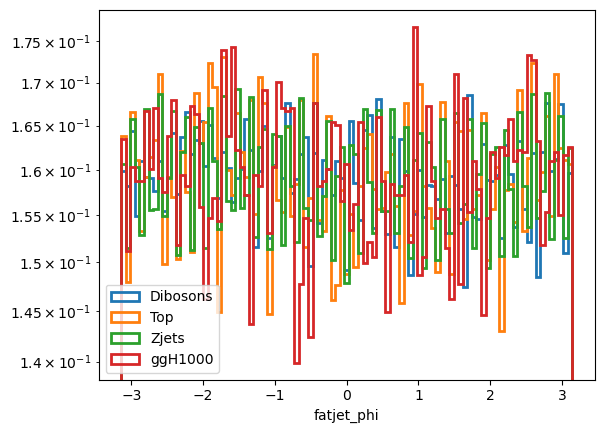

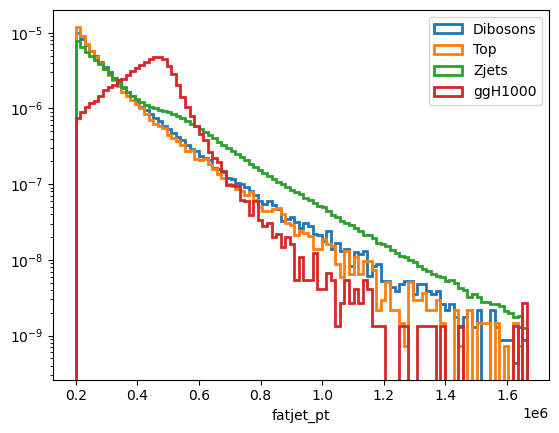

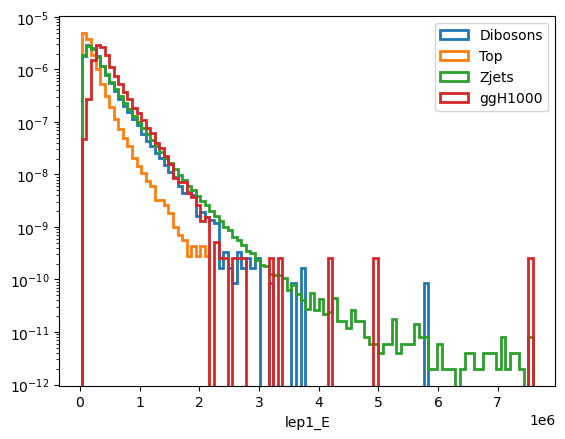

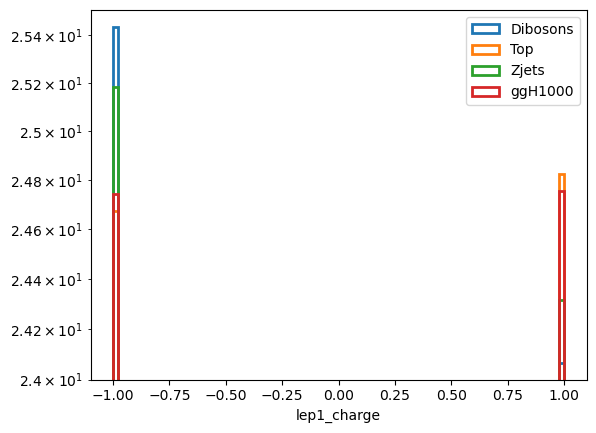

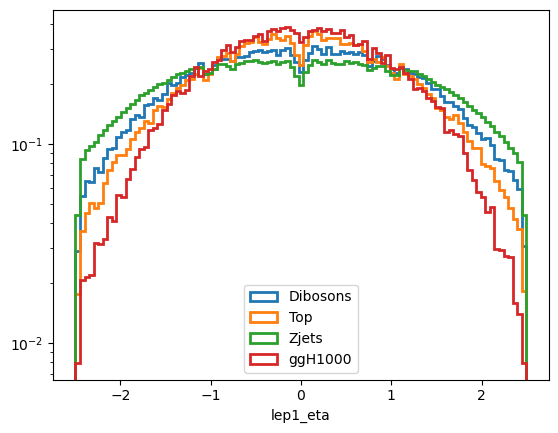

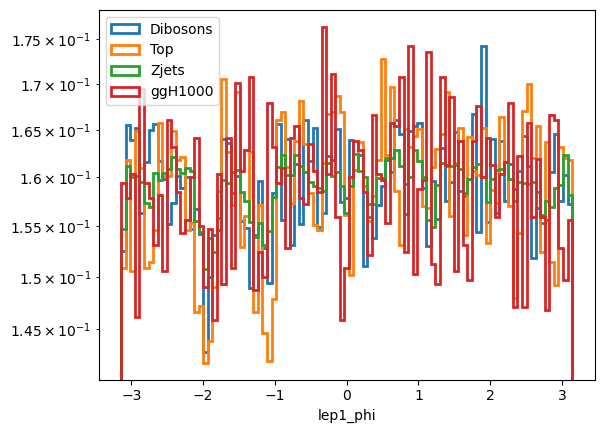

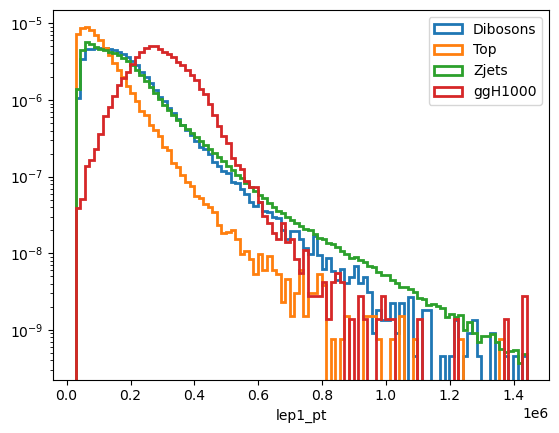

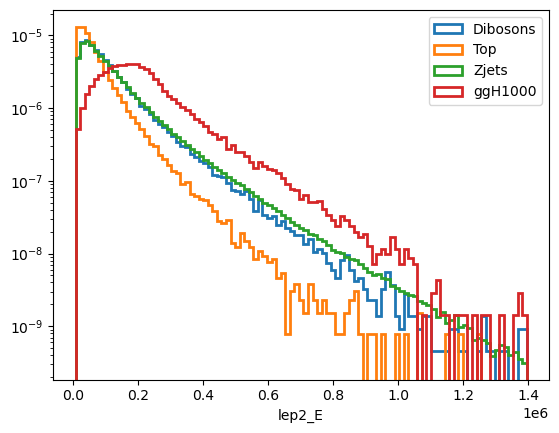

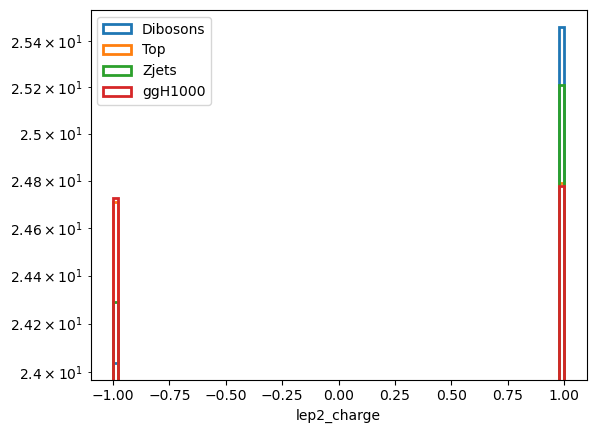

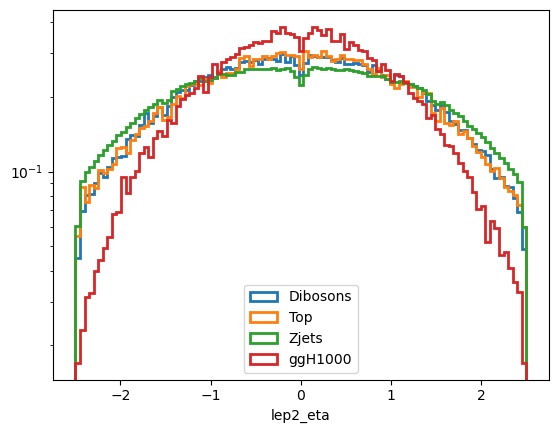

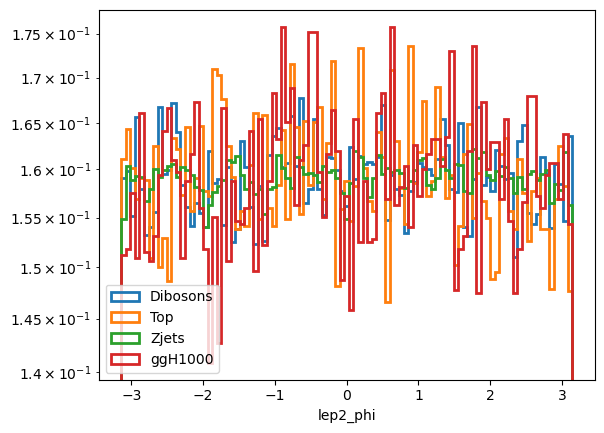

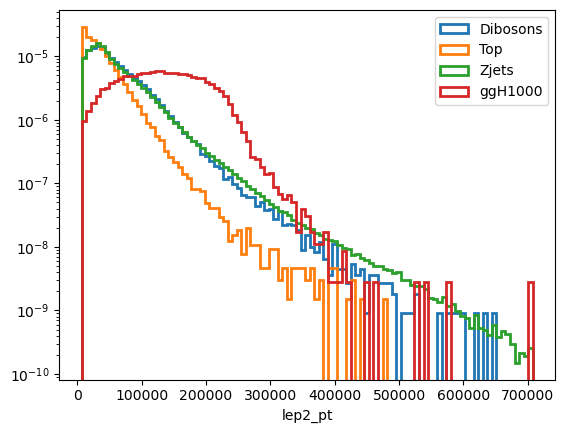

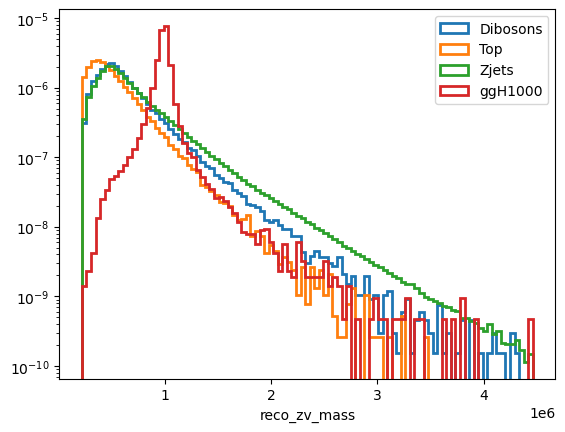

C:\Users\ls3007\.conda\envs\AGQenv\Lib\site-packages\numpy\lib\histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


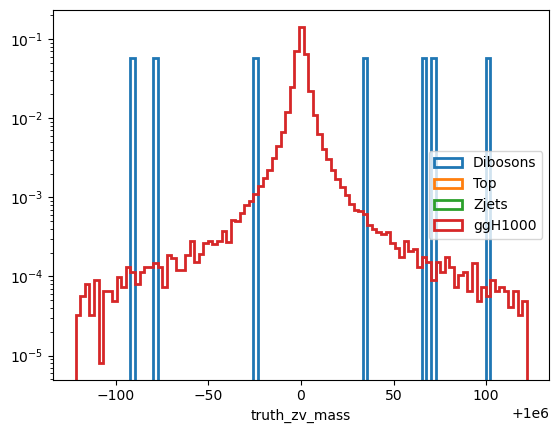

In [5]:
import numpy as np
features = [col for col in sig_df[0].columns if col != 'isSignal']

Nbins = 100
for var in features:
    #adopt a common binning scheme for all channels
    bins_ = np.linspace(min(sig_df[0][var]), max(sig_df[0][var]), Nbins)
    
    plt.hist(bgd_df[0][var], histtype='step', density=True, bins=bins_, label='Dibosons', linewidth=2)
    plt.hist(bgd_df[1][var], histtype='step', density=True, bins=bins_, label='Top', linewidth=2)
    plt.hist(bgd_df[2][var], histtype='step', density=True, bins=bins_, label='Zjets', linewidth=2)
    plt.hist(sig_df[0][var], histtype='step', density=True, bins=bins_, label='ggH1000', linewidth=2)         
     
    plt.xlabel(var)
    plt.yscale('log')
    plt.legend(loc='best')
    plt.show()

### Assessment Exercise 2: Create the dataset for the classifier; plot correlations in features to see some differences between signal and background

In [6]:
output = ['isSignal']
wtype = ['Background', 'Signal']

In [7]:
# put together all background samples to produce one mega-DataFrame
totalBgd_df = pd.concat(bgd_df, ignore_index = True)
print ("total # of bgd events =",totalBgd_df.shape[0])
print ("total # of sig events =",sig_df[0].shape[0])

total # of bgd events = 6826959
total # of sig events = 50013


In [8]:
# randomise the background samples
# previously, we randomised (shuffled) the data while constructing pytorch dataloaders; this is a hands-on alternative

from sklearn.utils import shuffle

def Randomise(df, random_seed):
    df = shuffle(df, random_state=random_seed)
    df = df.reset_index(drop=True) # do not insert a new column with the new index
    return df

Answer_to_all_questions = 42            # random seed for reproducibility
print(totalBgd_df.iloc[:5,:12])
totalBgd_df = Randomise(totalBgd_df, Answer_to_all_questions)
print(totalBgd_df.iloc[:5,:12])

   FullEventWeight         MET  Topology    Zll_mass      Zll_pt  fatjet_C2  \
0         0.387345   41920.540         0  187549.810  374316.600   0.127114   
1         0.172328  225618.530         0   13106.807   51429.535   0.269517   
2         0.371392   42284.125         0   84519.230  153790.270   0.051175   
3         0.309902   42735.938         1   76138.640  102611.836   0.117028   
4         0.202772   70475.780         0   86138.000  141886.280   0.053951   

   fatjet_D2   fatjet_E  fatjet_eta  fatjet_phi  fatjet_pt  isSignal  
0   1.786927  353161.47   -0.001591    1.914456  345940.12         0  
1   2.296220  357617.66   -1.066937   -0.145452  218057.10         0  
2   3.360730  345472.30    0.704825   -2.816466  274339.25         0  
3   0.702838  476446.80    0.095546    1.012053  444837.44         0  
4   3.634348  799487.75   -1.828396   -2.406883  250422.77         0  
   FullEventWeight        MET  Topology  Zll_mass     Zll_pt  fatjet_C2  \
0         0.793987  2028

In [9]:
# create a new dataset with equal #s of signal and background events
Nsig = sig_df[0].shape[0]
sigbgd_tmp = [totalBgd_df[0: Nsig], sig_df[0]]
# merge these two dataframes into one
sigbgd = pd.concat(sigbgd_tmp)
# randomise the new sample with equal #s of signal and background
sigbgd = Randomise(sigbgd,10) # not sure if this is correct - I just picked a value for random_seed
# check out the new dataframe
print(sigbgd.head(5))
print ("total # of events =",sigbgd.shape[0])
print ("# of signal events in new DF =",len(sigbgd[sigbgd.isSignal == 1]))
print ("# of background events in new DF =", len(sigbgd[sigbgd.isSignal == 0]))

   FullEventWeight         MET  Topology   Zll_mass     Zll_pt  fatjet_C2  \
0         0.073116  28306.3730         1  96400.160  425415.75   0.000000   
1         0.072127   4963.1997         0  91816.195  585833.06   0.061703   
2         0.073169  40353.2300         1  91527.510  241145.94   0.113418   
3         0.069701  20718.9320         0  91934.520  469572.03   0.159771   
4         0.068515  83145.4200         1  91073.586  518398.56   0.099456   

   fatjet_D2    fatjet_E  fatjet_eta  fatjet_phi  ...  lep1_eta  lep1_phi  \
0   0.000000   582333.00   -1.245835   -1.127999  ...  0.024575  1.848748   
1   0.435146  1144795.20   -1.820470    0.343583  ... -0.953303 -2.605561   
2   0.839711   449523.40   -1.008978   -1.147958  ...  1.833968  1.938585   
3   1.560130   309217.30    0.427438    2.447968  ... -0.673857 -0.918424   
4   0.824877   320858.47   -0.262700   -2.473178  ...  0.642300  1.081049   

     lep1_pt     lep2_E  lep2_charge  lep2_eta  lep2_phi    lep2_pt  \
0  

In [10]:
features = ['lep1_pt', 'lep2_E', 'lep2_charge', 'lep2_eta', 'lep2_phi', 'lep2_pt', 'reco_zv_mass', 'truth_zv_mass'] ## FINISH ME using just the first eight features from Table 1

# reduce to desired features + output
dataset = sigbgd[features + output]
print (dataset.shape)

(100026, 9)


In [11]:
data = dataset[features].values
target = dataset[output].values
print (data.shape, target.shape)

(100026, 8) (100026, 1)


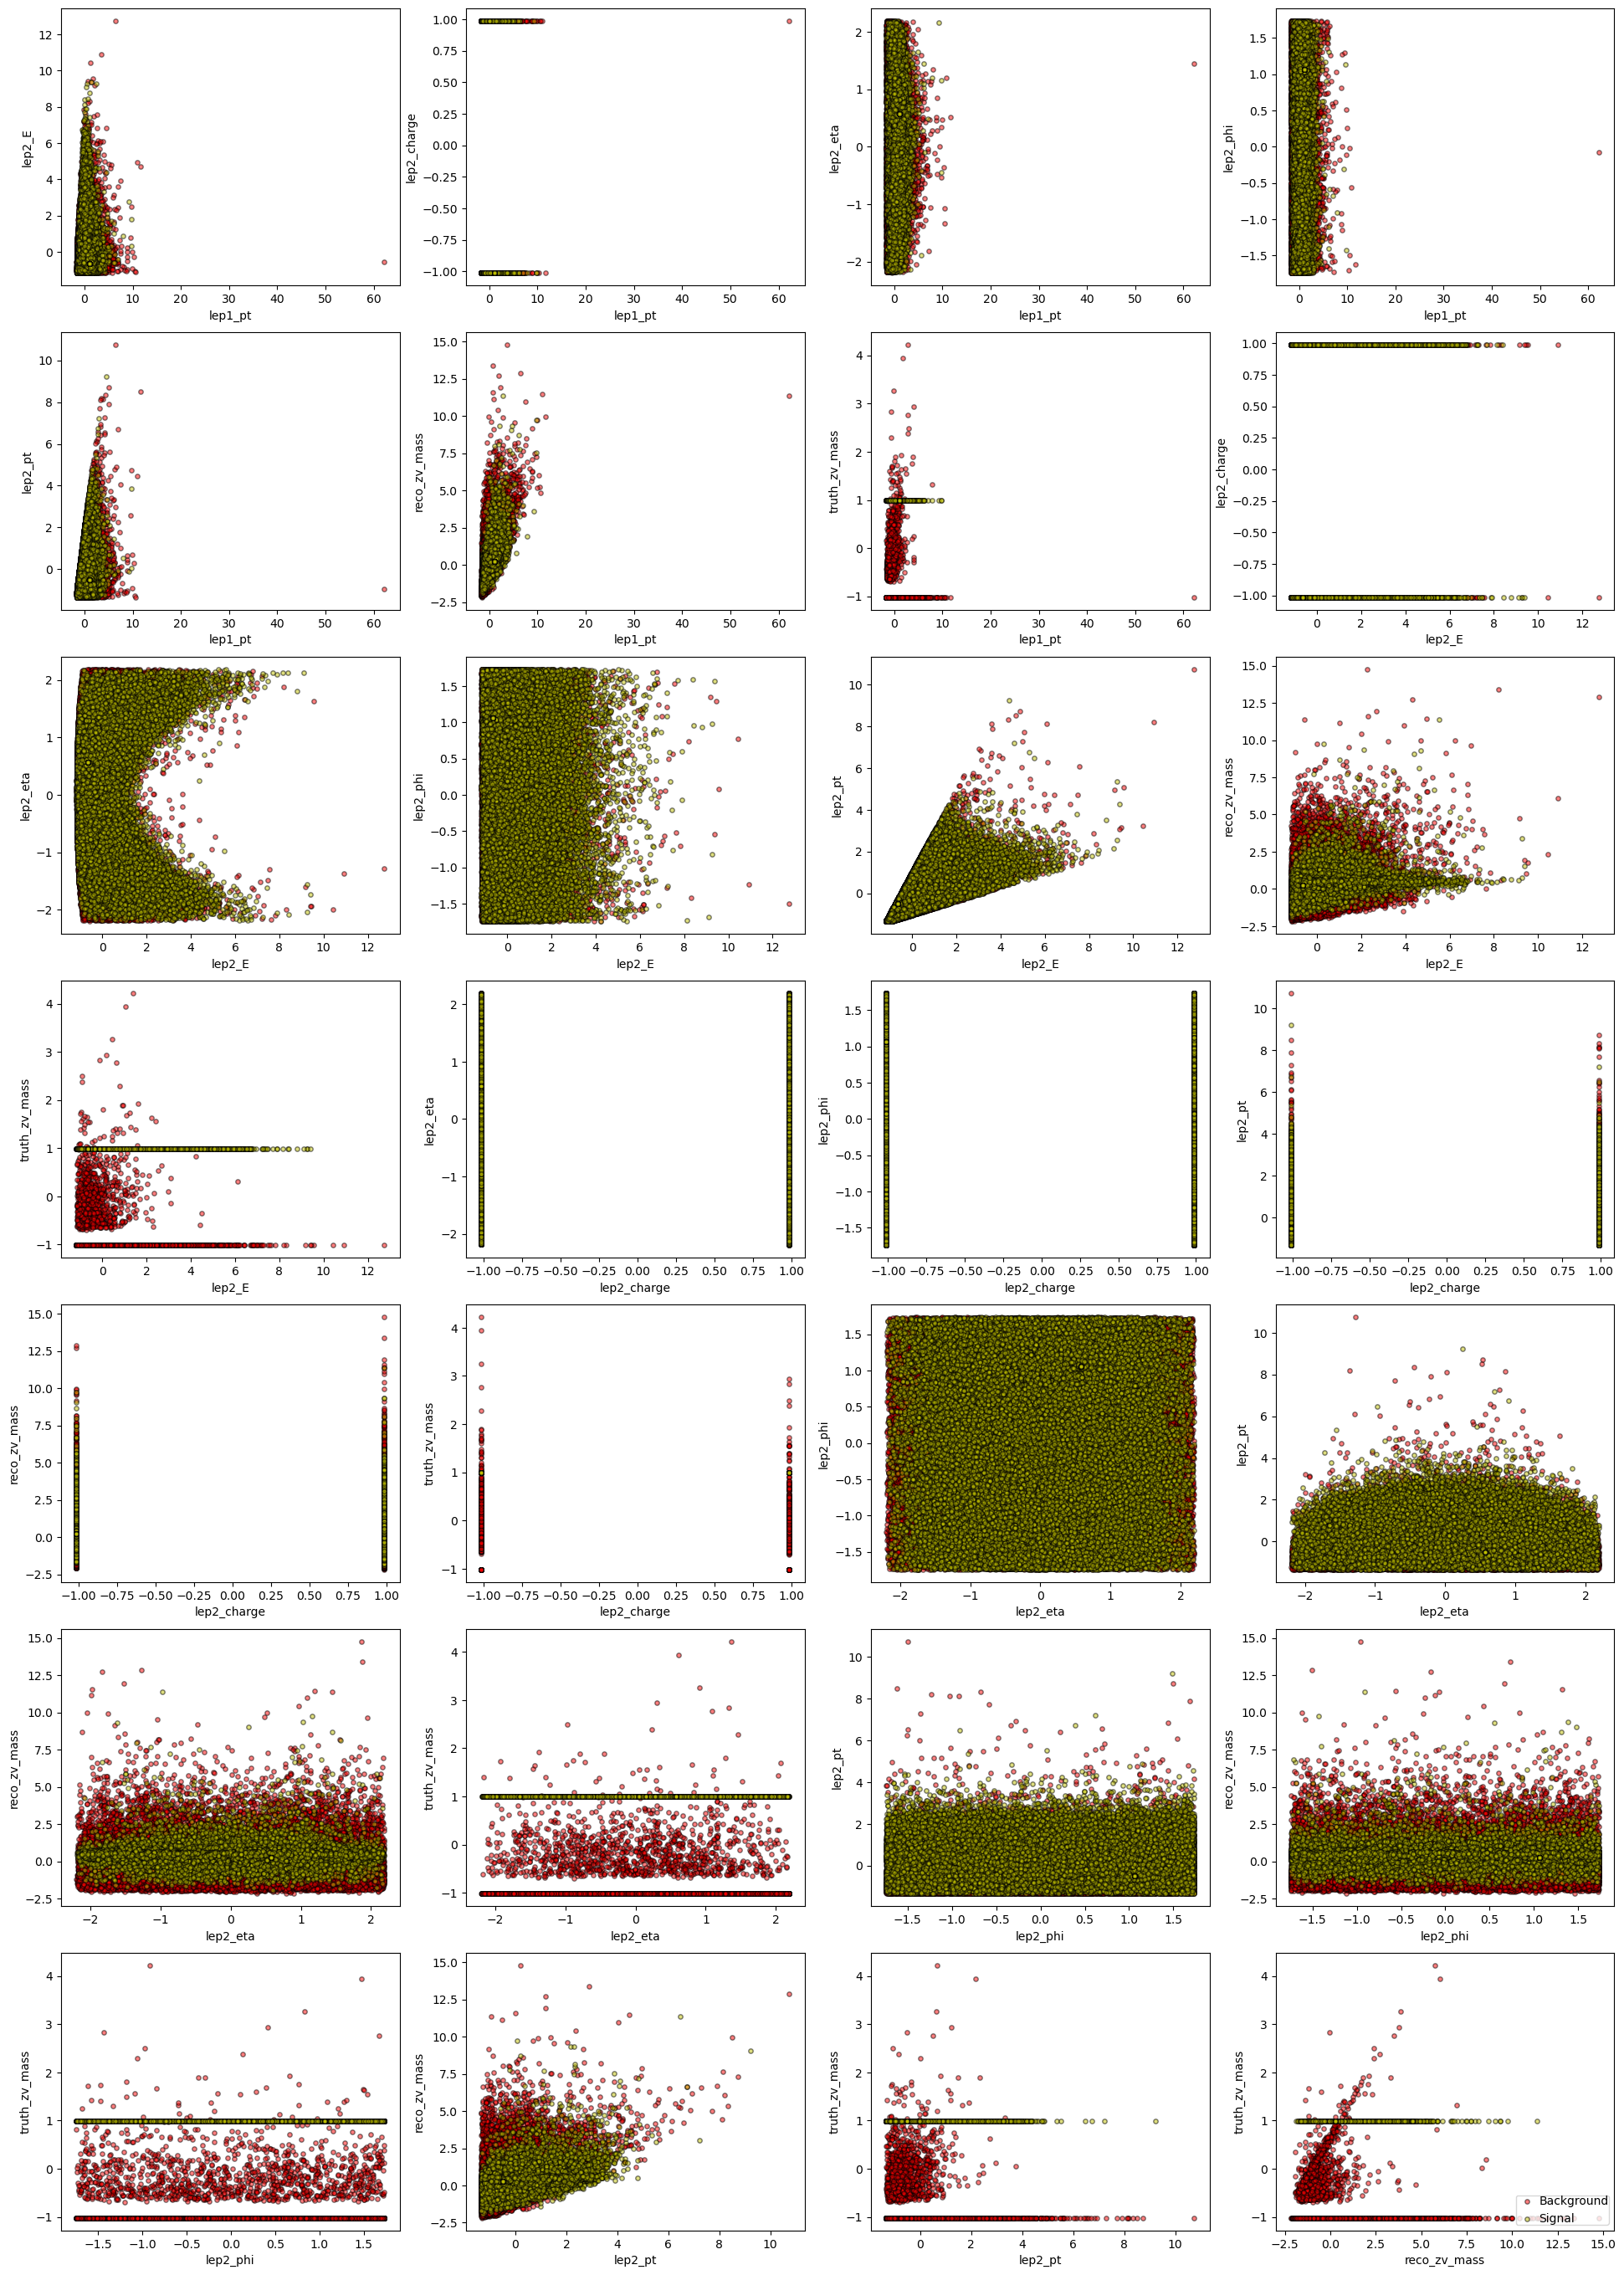

In [34]:
!pip install seaborn
import dt_utils
from dt_utils import featureplot
N_classes = 2
featureplot(data, target, N_classes, t_names = features, c_names = wtype)

# if you have 9 features, this will create (9 choose 2) = 9!/(2! 7!) = 36 plots. 
# if you have 8 features, this will create (8 choose 2) = 8!/(2! 6!) = 28 plots.

### Assessment Exercise 3: Rescale data and convert to PyTorch tensor

In [35]:
# feature scaling: we will now standardise the inputs (=scale their ranges so that they are roughly the same)
# recall that, previously, we used torchvision transforms while loading datasets to do something similar; this is an alternative
from sklearn import model_selection, preprocessing
sc = preprocessing.StandardScaler()
data = sc.fit_transform(data)

In [16]:
Answer_to_all_questions = 42

# train-test split of dataset and convert to pytorch tensors
train_data, test_data, train_target, test_target = model_selection.train_test_split(
    data, target, test_size=0.3, random_state=Answer_to_all_questions)

print(train_data.shape, train_target.shape, test_data.shape, test_target.shape)

import torch

def xNumpyToTensor(array):
    array = np.array(array, dtype=np.float32) 
    return torch.from_numpy(array).type(torch.FloatTensor)

def yNumpyToTensor(array):
    array = np.array(array.astype(int))
    return torch.from_numpy(array).type(torch.FloatTensor)

train_data_tensor = xNumpyToTensor(train_data)
train_target_tensor = yNumpyToTensor(train_target)
test_data_tensor = xNumpyToTensor(test_data)
test_target_tensor = yNumpyToTensor(test_target)


(70018, 8) (70018, 1) (30008, 8) (30008, 1)


### Assessment Exercise 4: construct and train the NN

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score, log_loss

In [26]:
N_epochs = 200
num_nodes = 40
num_inputs = 8    # num of inputs = 8 or 9
num_outputs = 1   # num of outputs = 1

In [29]:
dropout = nn.Dropout(p=0.2)     # see https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html

# Define a PyTorch NN with just one hidden layer of width num_nodes
# so num_inputs -> num_nodes -> num_nodes -> num_outputs
# with activation function ReLu and dropout after the first two transformations, and a final Sigmoid activation function
# altogether:  8 (or 9) -> 40, ReLu, dropout -> 40, ReLu, dropout -> 1, Sigmoid
# (Think: why a final Sigmoid function?)

def my_model(num_inputs, num_nodes):
    model = nn.Sequential(
		nn.Linear(num_inputs, num_nodes) , nn.ReLU(), dropout, 
		nn.Linear(num_nodes, num_nodes), nn.ReLU(), dropout, 
		nn.Linear(num_nodes, 1),  nn.Sigmoid()
	)
    return model

In [30]:
model = my_model(num_inputs, num_nodes)

In [37]:


# Train the model
loss_fn   = nn.BCELoss()  # binary cross entropy
optimizer = optim.Adam(model.parameters(), lr=0.001)
all_losses = []
all_valid_accuracies = []

#Training in batches
for step in range(N_epochs):    
    model.train()
    out = model(train_data_tensor)                 # input x and predict based on x
    cost = loss_fn(out, train_target_tensor)
    optimizer.zero_grad()   # clear gradients for next train
    cost.backward()         # backpropagation, compute gradients
    optimizer.step()        # apply gradients 

    step_size = 10
    
    loss = cost.item()
    all_losses.append(loss)
    if step % step_size == 0:        
        print(step, cost.data.cpu().numpy())

    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        prediction = model(test_data_tensor)  # probabilities
        predicted_labels = (prediction > 0.5).float()  # Convert probabilities to 0 or 1
        actual_labels = test_target_tensor
        accuracy = (predicted_labels.eq(actual_labels).sum() / float(actual_labels.nelement())).item()  # Calculate the accuracy
        all_valid_accuracies.append(accuracy)
        if step % step_size == 0:        
            print('Validation accuracy: {:.1f}%'.format(accuracy * 100))
        
    # RuntimeError: can't convert CUDA tensor to numpy (it doesn't support GPU arrays). 
    # Use .cpu() to move the tensor to host memory first.        
    ####prediction = (model(test_data_tensor).data).float() # probabilities                  
    pred_y = prediction.cpu().numpy().squeeze()
    target_y = test_target_tensor.cpu().data.numpy()
    if step % step_size == 0:        
        print ('LOG_LOSS={} '.format(log_loss(target_y, pred_y))) 



0 0.7049552
Validation accuracy: 50.6%
LOG_LOSS=0.6997099964850392 
10 0.6537124
Validation accuracy: 88.1%
LOG_LOSS=0.6479215529889033 
20 0.5958615
Validation accuracy: 95.9%
LOG_LOSS=0.5862378653304591 
30 0.517329
Validation accuracy: 96.8%
LOG_LOSS=0.5029001322010894 
40 0.42097518
Validation accuracy: 97.0%
LOG_LOSS=0.4013866330120456 
50 0.3196901
Validation accuracy: 97.3%
LOG_LOSS=0.2981838857289288 
60 0.23252706
Validation accuracy: 97.7%
LOG_LOSS=0.21041676811044308 
70 0.16507523
Validation accuracy: 98.4%
LOG_LOSS=0.14459551867191928 
80 0.116616085
Validation accuracy: 99.0%
LOG_LOSS=0.09796905957791577 
90 0.08422271
Validation accuracy: 99.4%
LOG_LOSS=0.06683755580778741 
100 0.06213529
Validation accuracy: 99.6%
LOG_LOSS=0.047563558032132434 
110 0.04822058
Validation accuracy: 99.7%
LOG_LOSS=0.0361121391614965 
120 0.0386545
Validation accuracy: 99.7%
LOG_LOSS=0.02921723376444962 
130 0.033899605
Validation accuracy: 99.7%
LOG_LOSS=0.024900593516584732 
140 0.0297132

#### Now plot the losses (all_losses) and the accuracies (all_valid_accuracies) across all training epochs.

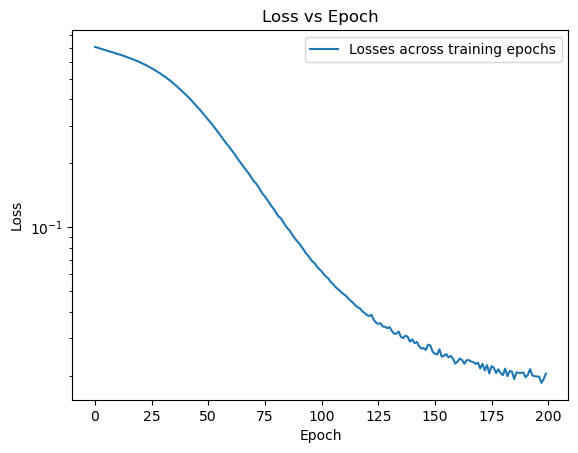

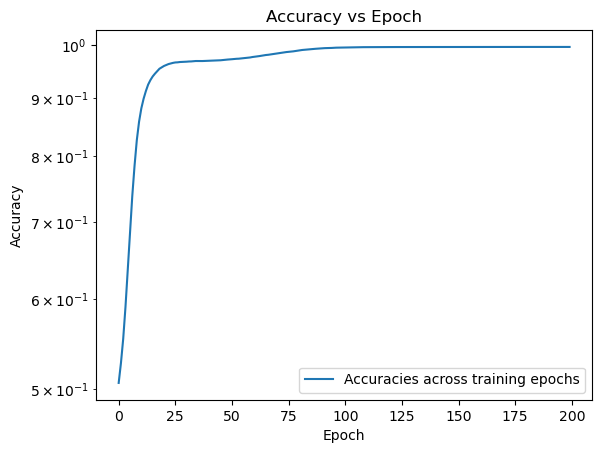

In [38]:
plt.plot(all_losses, label='Losses across training epochs')

# Add labels, legend, make log and plot
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.yscale('log')
plt.show()

plt.plot(all_valid_accuracies, label='Accuracies across training epochs')

# Add labels, legend, make log and plot
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.yscale('log')
plt.show()

### Assessment Exercise 5: Improve the NN

In [ ]:
# Your code here!   ## FINISH ME
# Try to get better than 95% accuracy.



### Assessment Exercise 6: Visualise what's happening

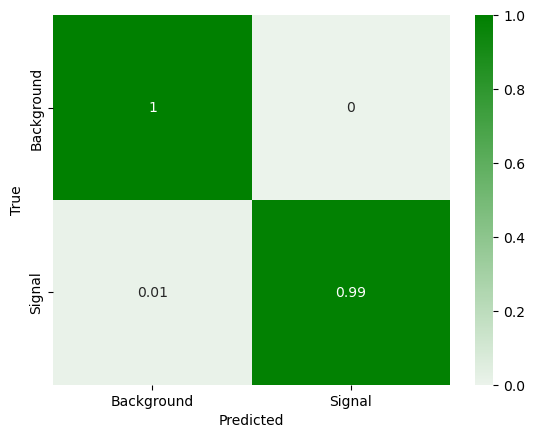

In [50]:
# Plot a confusion matrix

import seaborn as sns
import nn_utils
cm = confusion_matrix(predicted_labels, actual_labels)
nn_utils.heatmap(cm, labels=['Predicted', 'True'], 
        classes=[wtype,wtype],
        normalize=True)
#sns.heatmap(cm, annot=True)
plt.show()

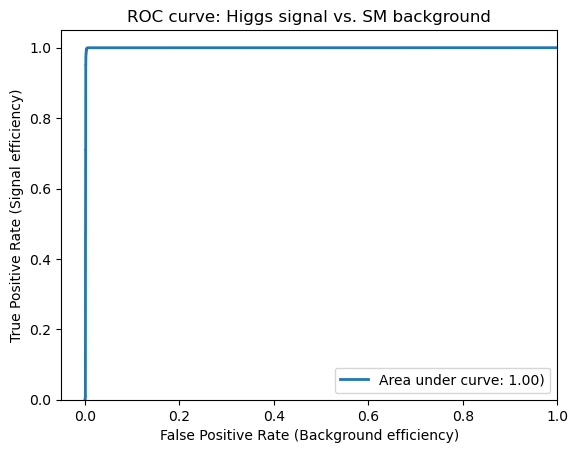

In [44]:
from sklearn import metrics
from sklearn.metrics import roc_curve, auc
# Get 'Receiver operating characteristic' (ROC)
fpr, tpr, thresholds = roc_curve(test_target, pred_y)

# Compute "Area Under the Curve" (AUC) from prediction scores
roc_auc  = auc(fpr, tpr)
plt.plot(fpr, tpr, lw=2, label='Area under curve: %0.2f)' % roc_auc)
plt.plot([0, 0], [1, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.ylabel('True Positive Rate (Signal efficiency)')
plt.xlabel('False Positive Rate (Background efficiency)')
plt.title('ROC curve: Higgs signal vs. SM background')
plt.legend(loc="best")
plt.show()